# Iron-Ore Pellet Physical-Market Analysis

This notebook is read-only with respect to raw data. The strict-cash analytical scope accepts only `ContractType` values `نقدی` and `نقدی (مچینگ)` when `Tasvieh` is exactly `نقدی`, with positive price and quantity. Cash/credit settlement is excluded even when the contract label is cash.

The source `Price` is the analytical physical price; `TotalPrice / Quantity` is an independent consistency check. The objective is an exploratory domestic benchmark for measuring the warehouse-receipt premium or discount. External intrinsic-value models are outside scope.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 100)

RAW_CSV = Path("../data/raw/physical/pellet_physical_raw.csv")
if not RAW_CSV.exists():
    raise FileNotFoundError(f"Run this notebook from {Path.cwd()} or correct RAW_CSV: {RAW_CSV}")

raw = pd.read_csv(RAW_CSV, encoding="utf-8-sig", low_memory=False)
numeric_columns = ["Price", "Quantity", "TotalPrice", "MinPrice", "MaxPrice", "arze", "taghaza"]
for column in numeric_columns:
    raw[column] = pd.to_numeric(raw[column], errors="coerce")

raw["date_jalali"] = raw["date"].astype(str).str.replace("-", "/", regex=False)
cash_contracts = ["نقدی", "نقدی (مچینگ)"]
cash_settlement = "نقدی"
cash = raw.loc[
    raw["ContractType"].isin(cash_contracts)
    & raw["Tasvieh"].eq(cash_settlement)
    & raw["Quantity"].gt(0)
    & raw["Price"].gt(0)
].copy()

print(f"Raw rows: {len(raw):,}")
print(f"Strict-cash rows (cash/cash-matching contract and cash settlement): {len(cash):,}")
print(f"Dates: {cash['date_jalali'].nunique():,}")
print(f"Traded symbols: {cash['Symbol'].nunique():,}")


Raw rows: 3,535
Strict-cash rows (cash/cash-matching contract and cash settlement): 273
Dates: 139
Traded symbols: 13


## 1. Price validation
`Price` is the reported price of the commodity exchange. The ratio `TotalPrice / Quantity` is simply its independent control. The maximum difference of 0.5 rials can result from rounding the price.

In [2]:
cash["price_from_value_quantity"] = cash["TotalPrice"] / cash["Quantity"]
cash["price_validation_abs_diff"] = (cash["Price"] - cash["price_from_value_quantity"]).abs()

price_validation = pd.Series({
    "rows": len(cash),
    "missing_total_price": int(cash["TotalPrice"].isna().sum()),
    "exact_matches": int(cash["price_validation_abs_diff"].eq(0).sum()),
    "maximum_absolute_difference": cash["price_validation_abs_diff"].max(),
    "maximum_relative_difference_pct": (100 * cash["price_validation_abs_diff"] / cash["Price"]).max(),
})
display(price_validation.to_frame("value"))

if cash["price_validation_abs_diff"].max() > 0.51:
    raise ValueError("Price no longer agrees with TotalPrice / Quantity within rounding tolerance.")


,value
rows,273.000000
missing_total_price,0.000000
exact_matches,267.000000
maximum_absolute_difference,0.500000
maximum_relative_difference_pct,0.000672


## 2. Identification of companies and symbols
The symbol (`Symbol`) is the stable identifier of the company in the analysis; Because the names of some manufacturers have been changed throughout history.

In [3]:
company_profile = (
    cash.groupby("Symbol", as_index=False)
    .agg(
        producer_names=("ProducerName", lambda values: " | ".join(sorted(set(values.dropna().astype(str))))),
        first_date=("date_jalali", "min"),
        last_date=("date_jalali", "max"),
        trade_days=("date_jalali", "nunique"),
        rows=("Quantity", "size"),
        volume=("Quantity", "sum"),
    )
    .sort_values("volume", ascending=False)
)
company_profile["volume_share_pct"] = 100 * company_profile["volume"] / company_profile["volume"].sum()
display(company_profile)


,Symbol,producer_names,first_date,last_date,trade_days,rows,volume,volume_share_pct
6,GOLG-PELL-00,معدنی و صنعتی گل گهر,1400/03/02,1405/05/25,51,68,2935000.0,35.318893
5,GHZ-PELL-00,سنگ آهن گهر زمین | معدنی و صنعتی گهر زمین (سنگ...,1400/04/27,1405/05/05,49,59,2816000.0,33.886883
10,SMO-PELL-00,صنعتی و معدنی اپال پارسیان سنگان,1400/02/26,1404/08/11,18,21,630000.0,7.581227
8,MKC-PELL-00,ماد کوش | مادکوش,1401/04/25,1404/02/07,13,13,545000.0,6.558363
7,MIIO-PELL-00,سنگ آهن مرکزی ایران,1400/10/19,1405/02/27,29,30,472000.0,5.679904
2,CHMI-PELL-00,شرکت معدنی وصنعتی چادرملو,1401/02/10,1401/10/10,11,12,300000.0,3.610108
9,SIS-PELL-00,فولاد سیرجان ایرانیان,1397/04/30,1404/11/19,14,15,257000.0,3.092659
3,FZI-PELL-00,شرکت فولاد زرند ایرانیان,1397/05/01,1404/11/26,18,21,153000.0,1.841155
12,SSMI-PELL-00,صنایع معدنی فولاد سنگان خراسان,1404/12/03,1405/05/25,9,18,90000.0,1.083032
1,BISC-PELL-00,فولاد بوتیای ایرانیان,1400/09/08,1404/10/28,3,5,45000.0,0.541516


## 3. Daily producer prices

For each producer and contract type, the daily price is volume weighted across eligible rows. A combined cash and cash-matching series is then calculated for cross-producer comparison. Weighting never crosses producers or dates.


In [4]:
cash["price_x_quantity"] = cash["Price"] * cash["Quantity"]

daily_company_contract = (
    cash.groupby(["date_jalali", "Symbol", "ContractType"], as_index=False)
    .agg(
        price_x_quantity=("price_x_quantity", "sum"),
        quantity=("Quantity", "sum"),
        rows=("Quantity", "size"),
        producer_name=("ProducerName", "last"),
    )
)
daily_company_contract["weighted_price"] = (
    daily_company_contract["price_x_quantity"] / daily_company_contract["quantity"]
)

daily_company = (
    cash.groupby(["date_jalali", "Symbol"], as_index=False)
    .agg(
        price_x_quantity=("price_x_quantity", "sum"),
        quantity=("Quantity", "sum"),
        rows=("Quantity", "size"),
        producer_name=("ProducerName", "last"),
        contract_count=("ContractType", "nunique"),
    )
)
daily_company["weighted_price"] = daily_company["price_x_quantity"] / daily_company["quantity"]

display(daily_company_contract.head())
display(daily_company.head())


,date_jalali,Symbol,ContractType,price_x_quantity,quantity,rows,producer_name,weighted_price
0,1397/04/13,ARSC-PELL-00,نقدی,26150000.0,5000.0,1,ذوب فولاد اردکان,5230.0
1,1397/04/30,SIS-PELL-00,نقدی,55180000.0,10000.0,1,فولاد سیرجان ایرانیان,5518.0
2,1397/05/01,FZI-PELL-00,نقدی,52300000.0,10000.0,1,شرکت فولاد زرند ایرانیان,5230.0
3,1397/07/01,SIS-PELL-00,نقدی,75050000.0,10000.0,1,فولاد سیرجان ایرانیان,7505.0
4,1398/02/28,SIS-PELL-00,نقدی,93470000.0,10000.0,1,فولاد سیرجان ایرانیان,9347.0


,date_jalali,Symbol,price_x_quantity,quantity,rows,producer_name,contract_count,weighted_price
0,1397/04/13,ARSC-PELL-00,26150000.0,5000.0,1,ذوب فولاد اردکان,1,5230.0
1,1397/04/30,SIS-PELL-00,55180000.0,10000.0,1,فولاد سیرجان ایرانیان,1,5518.0
2,1397/05/01,FZI-PELL-00,52300000.0,10000.0,1,شرکت فولاد زرند ایرانیان,1,5230.0
3,1397/07/01,SIS-PELL-00,75050000.0,10000.0,1,فولاد سیرجان ایرانیان,1,7505.0
4,1398/02/28,SIS-PELL-00,93470000.0,10000.0,1,فولاد سیرجان ایرانیان,1,9347.0


## 4. Cash versus cash-matching prices on common producer-dates


In [5]:
cash_vs_matching = (
    daily_company_contract.pivot_table(
        index=["date_jalali", "Symbol"],
        columns="ContractType",
        values="weighted_price",
        aggfunc="first",
    )
    .dropna(subset=cash_contracts)
    .reset_index()
)
cash_vs_matching["matching_vs_cash_pct"] = 100 * (
    cash_vs_matching["نقدی (مچینگ)"] / cash_vs_matching["نقدی"] - 1
)
display(cash_vs_matching["matching_vs_cash_pct"].describe())
display(cash_vs_matching.reindex(cash_vs_matching["matching_vs_cash_pct"].abs().sort_values(ascending=False).index).head(20))


count    50.0
mean      0.0
std       0.0
min       0.0
25%       0.0
50%       0.0
75%       0.0
max       0.0
Name: matching_vs_cash_pct, dtype: float64

ContractType,date_jalali,Symbol,نقدی,نقدی (مچینگ),matching_vs_cash_pct
0,1400/03/30,SMO-PELL-00,36500.0,36500.0,0.0
1,1400/04/13,GOLG-PELL-00,36500.0,36500.0,0.0
2,1400/05/31,SMO-PELL-00,37000.0,37000.0,0.0
3,1400/08/30,GOLG-PELL-00,38500.0,38500.0,0.0
4,1400/09/08,BISC-PELL-00,37209.0,37209.0,0.0
5,1400/10/12,GOLG-PELL-00,38473.0,38473.0,0.0
6,1400/11/16,BISC-PELL-00,36216.0,36216.0,0.0
7,1400/11/23,GHZ-PELL-00,36114.0,36114.0,0.0
8,1400/12/07,GOLG-PELL-00,37366.0,37366.0,0.0
9,1400/12/21,SMO-PELL-00,39839.0,39839.0,0.0


## 5. Price chart of major companies
Change the `TOP_N` parameter to increase or decrease the number of companies.

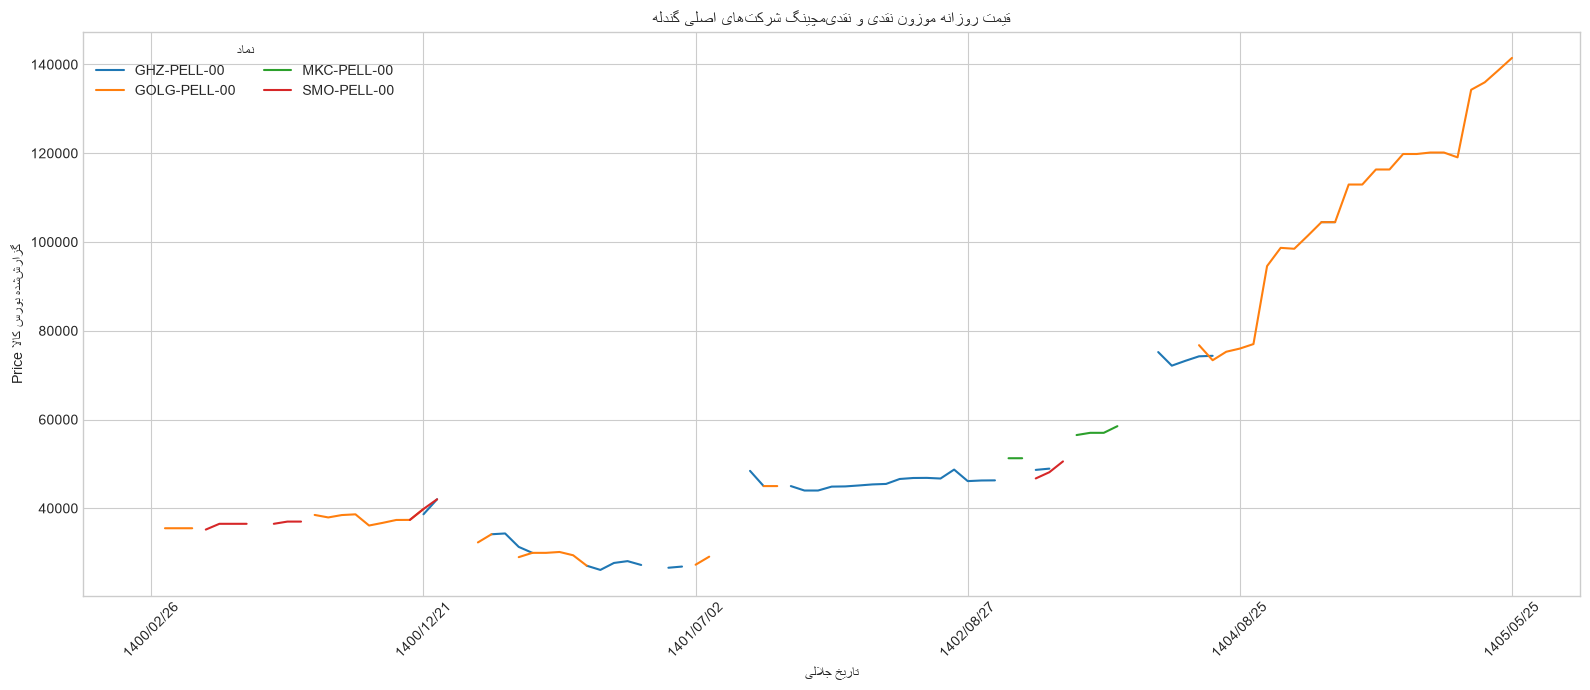

In [6]:
TOP_N = 4
top_symbols = company_profile.head(TOP_N)["Symbol"].tolist()
plot_data = daily_company.loc[daily_company["Symbol"].isin(top_symbols)].copy()
price_wide = plot_data.pivot(index="date_jalali", columns="Symbol", values="weighted_price").sort_index()

ax = price_wide.plot(figsize=(16, 7), linewidth=1.5)
ax.set_title("قیمت روزانه موزون نقدی و نقدی‌مچینگ شرکت‌های اصلی گندله")
ax.set_xlabel("تاریخ جلالی")
ax.set_ylabel("Price گزارش‌شده بورس کالا")
ax.legend(title="نماد", ncol=2)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 6. The distance of the price of each company from the weighted price of the whole market on the same day
This conversion reduces the effect of the general price trend and is more suitable for recognizing premium or stable discount of companies.

,count,mean,median,std,min,max,volume_share_pct
Symbol,,,,,,,
GOLG-PELL-00,51,0.578091,0.000000,1.304355,-1.998769,6.236198,35.318893
GHZ-PELL-00,49,0.081553,0.000000,1.104680,-2.767760,5.817798,33.886883
SMO-PELL-00,18,-0.990597,0.000000,3.310845,-13.218001,1.422669,7.581227
MKC-PELL-00,13,0.423061,0.000000,1.529770,-0.014633,5.514427,6.558363
MIIO-PELL-00,29,-0.749962,0.000000,2.407199,-9.437811,0.395576,5.679904
CHMI-PELL-00,11,0.026355,0.000000,0.068075,0.000000,0.222285,3.610108
SIS-PELL-00,14,-0.441418,0.000000,1.675758,-4.370173,1.677216,3.092659
FZI-PELL-00,18,-2.730417,-2.222307,2.918028,-8.045625,0.000000,1.841155
SSMI-PELL-00,9,-2.160502,-3.258113,4.203882,-7.093791,7.142716,1.083032


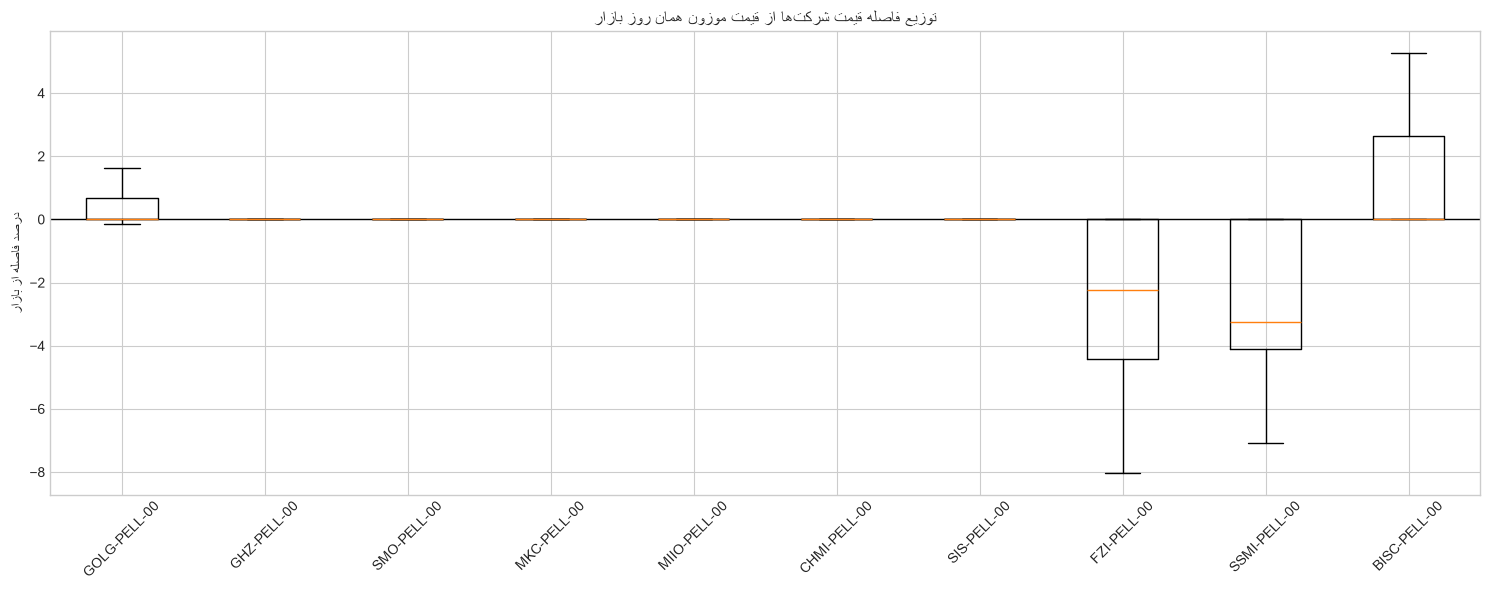

In [7]:
daily_market = (
    daily_company.groupby("date_jalali", as_index=False)
    .agg(price_x_quantity=("price_x_quantity", "sum"), quantity=("quantity", "sum"))
)
daily_market["market_weighted_price"] = daily_market["price_x_quantity"] / daily_market["quantity"]
comparison = daily_company.merge(daily_market[["date_jalali", "market_weighted_price"]], on="date_jalali", how="left")
comparison["company_vs_market_pct"] = 100 * (comparison["weighted_price"] / comparison["market_weighted_price"] - 1)

premium_summary = (
    comparison.groupby("Symbol")["company_vs_market_pct"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .join(company_profile.set_index("Symbol")[["volume_share_pct"]])
    .sort_values("volume_share_pct", ascending=False)
)
display(premium_summary)

box_symbols = company_profile.head(10)["Symbol"]
box_data = [comparison.loc[comparison["Symbol"].eq(symbol), "company_vs_market_pct"].dropna() for symbol in box_symbols]
fig, ax = plt.subplots(figsize=(15, 6))
ax.boxplot(box_data, tick_labels=box_symbols, showfliers=False)
ax.axhline(0, color="black", linewidth=1)
ax.set_title("توزیع فاصله قیمت شرکت‌ها از قیمت موزون همان روز بازار")
ax.set_ylabel("درصد فاصله از بازار")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()


## 7. Cross-sectional comparison on a desired day
Select a date from dates with multiple companies.

,date_jalali,Symbol,producer_name,weighted_price,quantity,contract_count
222,1405/05/25,SSMI-PELL-00,صنایع معدنی فولاد سنگان خراسان,134670.0,5000.0,2
221,1405/05/25,GOLG-PELL-00,معدنی و صنعتی گل گهر,141473.0,20000.0,2


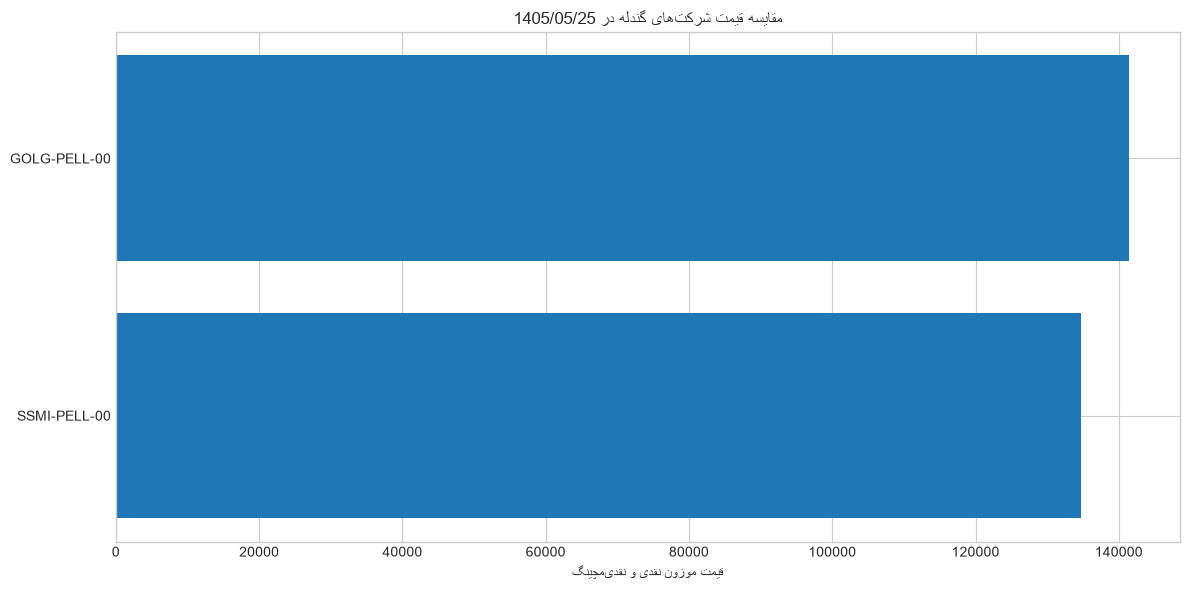

In [8]:
available_dates = (
    daily_company.groupby("date_jalali")["Symbol"].nunique().loc[lambda s: s >= 2].index.tolist()
)
SELECTED_DATE = available_dates[-1]
selected = daily_company.loc[daily_company["date_jalali"].eq(SELECTED_DATE)].sort_values("weighted_price")
display(selected[["date_jalali", "Symbol", "producer_name", "weighted_price", "quantity", "contract_count"]])

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(selected["Symbol"], selected["weighted_price"])
ax.set_title(f"مقایسه قیمت شرکت‌های گندله در {SELECTED_DATE}")
ax.set_xlabel("قیمت موزون نقدی و نقدی‌مچینگ")
plt.tight_layout()
plt.show()


## 8. Diagnostic output for decision making
These tables are built in memory and do not overwrite anything in raw. After viewing the charts, we decide on the appropriate combination of companies for the underlying.

In [9]:
daily_dispersion = (
    daily_company.groupby("date_jalali")
    .agg(
        company_count=("Symbol", "nunique"),
        minimum_price=("weighted_price", "min"),
        maximum_price=("weighted_price", "max"),
        total_quantity=("quantity", "sum"),
    )
    .reset_index()
)
daily_dispersion["max_min_spread_pct"] = 100 * (
    daily_dispersion["maximum_price"] / daily_dispersion["minimum_price"] - 1
)
display(daily_dispersion.describe())
display(daily_dispersion.sort_values("max_min_spread_pct", ascending=False).head(20))


,company_count,minimum_price,maximum_price,total_quantity,max_min_spread_pct
count,139.000000,139.000000,139.000000,139.000000,139.000000
mean,1.604317,54977.776978,56228.733813,59784.172662,1.570847
std,0.839416,29175.939294,30826.804007,75200.867497,3.696025
min,1.000000,5230.000000,5230.000000,1000.000000,0.000000
25%,1.000000,36187.500000,36358.000000,10500.000000,0.000000
50%,1.000000,45375.000000,45375.000000,33000.000000,0.000000
75%,2.000000,68511.000000,72680.500000,67500.000000,0.000000
max,4.000000,134670.000000,141473.000000,390000.000000,16.996334


,date_jalali,company_count,minimum_price,maximum_price,total_quantity,max_min_spread_pct
100,1404/08/11,3,63549.0,74350.0,147000.0,16.996334
119,1404/12/03,4,90548.0,104471.0,110000.0,15.376375
112,1404/10/21,2,83029.0,94566.0,40000.0,13.895145
127,1405/02/27,2,102579.0,116336.0,35000.0,13.411127
41,1401/04/11,4,27607.0,31299.0,250000.0,13.373420
134,1405/03/24,2,105090.0,119069.0,40000.0,13.301932
116,1404/11/12,3,87985.0,98679.0,85000.0,12.154344
123,1405/02/13,2,97355.0,108172.0,15000.0,11.110883
84,1402/11/28,3,48126.0,53100.0,195000.0,10.335370
117,1404/11/19,3,89892.0,98474.0,57000.0,9.547012


## 9. Producer representation and price homogeneity since certificate inception

This section examines strict-cash observations from the certificate start date, `1404/07/28`. Four candidate producers are identified by stable symbols. Volume shares and simultaneous trading dates are reported explicitly. Pairwise dispersion uses the symmetric percentage difference, `100 × |P1 - P2| / ((P1 + P2) / 2)`, so neither producer is treated as an arbitrary denominator.


In [10]:
from itertools import combinations

CERTIFICATE_START_DATE = "1404/07/28"
selected_companies = {
    "GOLG-PELL-00": "گل گهر",
    "GHZ-PELL-00": "گهر زمین",
    "SSMI-PELL-00": "سنگان خراسان",
    "CHMI-PELL-00": "چادرملو",
}
company_columns = list(selected_companies.values())

cash_since_certificate = cash.loc[cash["date_jalali"].ge(CERTIFICATE_START_DATE)].copy()
if cash_since_certificate.empty:
    raise ValueError(f"No positive cash trades found from {CERTIFICATE_START_DATE} onward")
available_symbols = set(cash_since_certificate["Symbol"].dropna())
missing_symbols = set(selected_companies) - available_symbols
if missing_symbols:
    print(f"No strict-cash trades for: {sorted(missing_symbols)}")
active_selected_companies = {
    symbol: company for symbol, company in selected_companies.items()
    if symbol in available_symbols
}
company_columns = list(active_selected_companies.values())

total_market_volume = cash_since_certificate["Quantity"].sum()
selected_trades = cash_since_certificate.loc[
    cash_since_certificate["Symbol"].isin(selected_companies)
].copy()
selected_trades["company"] = selected_trades["Symbol"].map(selected_companies)
selected_trades["price_x_quantity"] = selected_trades["Price"] * selected_trades["Quantity"]

company_volume_share = (
    selected_trades.groupby(["company", "Symbol"], as_index=False)
    .agg(
        first_trade_date=("date_jalali", "min"),
        last_trade_date=("date_jalali", "max"),
        trade_days=("date_jalali", "nunique"),
        trade_rows=("Quantity", "size"),
        traded_volume=("Quantity", "sum"),
    )
)
company_volume_share["market_volume_share_pct"] = (
    100 * company_volume_share["traded_volume"] / total_market_volume
)
company_volume_share = company_volume_share.sort_values("traded_volume", ascending=False).reset_index(drop=True)
display(company_volume_share)
print(
    "Active candidate share (Gol Gohar + Gohar Zamin + Sangan): "
    f"{company_volume_share['traded_volume'].sum() / total_market_volume * 100:.2f}%"
)

daily_company_selected = (
    selected_trades.groupby(["date_jalali", "company"], as_index=False)
    .agg(price_x_quantity=("price_x_quantity", "sum"), traded_volume=("Quantity", "sum"))
)
daily_company_selected["weighted_price_irr_per_kg"] = (
    daily_company_selected["price_x_quantity"] / daily_company_selected["traded_volume"]
)
daily_price_wide = daily_company_selected.pivot(
    index="date_jalali", columns="company", values="weighted_price_irr_per_kg"
).sort_index()
daily_price_wide = daily_price_wide.reindex(columns=company_columns)
daily_price_wide["traded_company_count"] = daily_price_wide[company_columns].notna().sum(axis=1)
simultaneous_days = daily_price_wide.loc[daily_price_wide["traded_company_count"].ge(2)].copy()
simultaneous_days["minimum_price_irr_per_kg"] = simultaneous_days[company_columns].min(axis=1)
simultaneous_days["maximum_price_irr_per_kg"] = simultaneous_days[company_columns].max(axis=1)
simultaneous_days["mean_price_irr_per_kg"] = simultaneous_days[company_columns].mean(axis=1)
simultaneous_days["max_min_difference_irr_per_kg"] = (
    simultaneous_days["maximum_price_irr_per_kg"] - simultaneous_days["minimum_price_irr_per_kg"]
)
simultaneous_days["max_min_spread_pct"] = (
    100 * simultaneous_days["max_min_difference_irr_per_kg"] / simultaneous_days["mean_price_irr_per_kg"]
)
simultaneous_days["price_cv_pct"] = (
    100 * simultaneous_days[company_columns].std(axis=1, ddof=0) / simultaneous_days["mean_price_irr_per_kg"]
)
display(simultaneous_days[company_columns + ["traded_company_count", "max_min_spread_pct", "price_cv_pct"]])

pairwise_results = []
for company_1, company_2 in combinations(company_columns, 2):
    pair = simultaneous_days[[company_1, company_2]].dropna()
    symmetric_difference_pct = (
        100 * (pair[company_1] - pair[company_2]).abs() / ((pair[company_1] + pair[company_2]) / 2)
    )
    pairwise_results.append({
        "company_1": company_1,
        "company_2": company_2,
        "common_trade_days": len(pair),
        "mean_symmetric_difference_pct": symmetric_difference_pct.mean(),
        "median_symmetric_difference_pct": symmetric_difference_pct.median(),
        "maximum_symmetric_difference_pct": symmetric_difference_pct.max(),
    })
pairwise_summary = pd.DataFrame(pairwise_results).sort_values("mean_symmetric_difference_pct").reset_index(drop=True)
display(pairwise_summary)

all_active_companies_days = simultaneous_days.loc[
    simultaneous_days["traded_company_count"].eq(len(company_columns))
]
homogeneity_summary = pd.Series({
    "days_with_at_least_two_companies": len(simultaneous_days),
    "active_company_count": len(company_columns),
    "days_with_all_active_companies": len(all_active_companies_days),
    "mean_daily_max_min_spread_pct": simultaneous_days["max_min_spread_pct"].mean(),
    "median_daily_max_min_spread_pct": simultaneous_days["max_min_spread_pct"].median(),
    "maximum_daily_max_min_spread_pct": simultaneous_days["max_min_spread_pct"].max(),
    "mean_daily_price_cv_pct": simultaneous_days["price_cv_pct"].mean(),
    "median_daily_price_cv_pct": simultaneous_days["price_cv_pct"].median(),
}, name="value")
display(homogeneity_summary.to_frame())
display(all_active_companies_days[company_columns + ["max_min_spread_pct", "price_cv_pct"]])


No strict-cash trades for: ['CHMI-PELL-00']


,company,Symbol,first_trade_date,last_trade_date,trade_days,trade_rows,traded_volume,market_volume_share_pct
0,گل گهر,GOLG-PELL-00,1404/08/04,1405/05/25,24,31,811000.0,55.738832
1,گهر زمین,GHZ-PELL-00,1404/08/04,1405/05/05,7,10,211000.0,14.501718
2,سنگان خراسان,SSMI-PELL-00,1404/12/03,1405/05/25,9,18,90000.0,6.185567


Active candidate share (Gol Gohar + Gohar Zamin + Sangan): 76.43%


company,گل گهر,گهر زمین,سنگان خراسان,traded_company_count,max_min_spread_pct,price_cv_pct
date_jalali,,,,,,
1404/08/04,76749.0,74240.0,NaN,2,3.323421,1.661710
1404/08/11,73358.0,74350.0,NaN,2,1.343191,0.671595
1404/09/30,76999.0,75856.0,NaN,2,1.495535,0.747767
1404/12/03,104471.0,104471.0,96465.0,3,7.864260,3.707248
1404/12/17,104471.0,104471.0,96465.0,3,7.864260,3.707248
1405/03/10,120159.0,120159.0,NaN,2,0.000000,0.000000
1405/05/05,134296.0,134296.0,128253.0,3,4.568282,2.153509
1405/05/11,135979.0,NaN,129440.0,2,4.927304,2.463652
1405/05/18,138699.0,NaN,132029.0,2,4.927455,2.463727


,company_1,company_2,common_trade_days,mean_symmetric_difference_pct,median_symmetric_difference_pct,maximum_symmetric_difference_pct
0,گل گهر,گهر زمین,7,0.880307,0.000000,3.323421
1,گل گهر,سنگان خراسان,6,5.887110,4.927379,7.968706
2,گهر زمین,سنگان خراسان,3,6.846915,7.968706,7.968706


,value
days_with_at_least_two_companies,10.000000
active_company_count,3.000000
days_with_all_active_companies,3.000000
mean_daily_max_min_spread_pct,4.124086
median_daily_max_min_spread_pct,4.747720
maximum_daily_max_min_spread_pct,7.864260
mean_daily_price_cv_pct,2.004004
median_daily_price_cv_pct,2.308544


company,گل گهر,گهر زمین,سنگان خراسان,max_min_spread_pct,price_cv_pct
date_jalali,,,,,
1404/12/03,104471.0,104471.0,96465.0,7.864260,3.707248
1404/12/17,104471.0,104471.0,96465.0,7.864260,3.707248
1405/05/05,134296.0,134296.0,128253.0,4.568282,2.153509


### Price-homogeneity finding

After imposing `Tasvieh == نقدی`, Chadormalu has no eligible strict-cash trades after certificate inception. Gol Gohar represents 55.31% of strict-cash volume, Gohar Zamin 14.76%, and Sangan Khorasan 5.94%. At least two candidates trade simultaneously on only nine dates. This sparse overlap is insufficient for a stable multi-producer daily index, so the broader all-trade volume evidence is used for producer selection and strict-cash observations are reserved for benchmark construction.


## 10. Statistical basis for benchmark-producer selection

Producer representation is measured using all positive physical-market trades since certificate inception, independent of contract or settlement type. The strict-cash rule is applied later, when constructing the benchmark price.


In [11]:
all_market_since_certificate = raw.loc[
    raw["date_jalali"].ge(CERTIFICATE_START_DATE)
    & raw["Quantity"].gt(0)
    & raw["Price"].gt(0)
].copy()

all_market_total_volume = all_market_since_certificate["Quantity"].sum()
all_market_selected_profile = (
    all_market_since_certificate.loc[
        all_market_since_certificate["Symbol"].isin(selected_companies)
    ]
    .assign(company=lambda frame: frame["Symbol"].map(selected_companies))
    .groupby(["company", "Symbol"], as_index=False)
    .agg(
        trade_rows=("Quantity", "size"),
        trade_days=("date_jalali", "nunique"),
        traded_volume=("Quantity", "sum"),
    )
)
all_market_selected_profile["all_market_volume_share_pct"] = (
    100 * all_market_selected_profile["traded_volume"] / all_market_total_volume
)
all_market_selected_profile = all_market_selected_profile.sort_values(
    "traded_volume", ascending=False
).reset_index(drop=True)
display(all_market_selected_profile)

leader_symbols = ["GOLG-PELL-00", "GHZ-PELL-00"]
excluded_symbols = ["SSMI-PELL-00", "CHMI-PELL-00"]
leader_share = all_market_selected_profile.loc[
    all_market_selected_profile["Symbol"].isin(leader_symbols),
    "all_market_volume_share_pct",
].sum()
excluded_share = all_market_selected_profile.loc[
    all_market_selected_profile["Symbol"].isin(excluded_symbols),
    "all_market_volume_share_pct",
].sum()
display(pd.Series({
    "all_market_total_volume": all_market_total_volume,
    "gol_gohar_and_gohar_zamin_share_pct": leader_share,
    "sangan_and_chadormalu_share_pct": excluded_share,
}, name="value").to_frame())


,company,Symbol,trade_rows,trade_days,traded_volume,all_market_volume_share_pct
0,گل گهر,GOLG-PELL-00,86,40,3794000.0,32.566524
1,گهر زمین,GHZ-PELL-00,65,44,2649000.0,22.738197
2,چادرملو,CHMI-PELL-00,40,33,1119000.0,9.605150
3,سنگان خراسان,SSMI-PELL-00,69,43,695000.0,5.965665


,value
all_market_total_volume,1.165000e+07
gol_gohar_and_gohar_zamin_share_pct,5.530472e+01
sangan_and_chadormalu_share_pct,1.557082e+01


Across all positive trades since certificate inception, total volume is 10,751,000 tonnes. Gol Gohar represents 3,306,000 tonnes (30.75%) and Gohar Zamin 2,484,000 tonnes (23.10%). Chadormalu represents 1,055,000 tonnes (9.81%) and Sangan Khorasan 608,000 tonnes (5.66%). The selected pair therefore covers 53.86% of the market, compared with 15.47% for the two excluded producers. Selection is based on market representation; no raw observation is deleted.


## 11. Historical sales volume of the four candidate producers

This section covers the full history of strict-cash and cash-matching transactions. Daily producer volume is the sum of `Quantity`. Monthly and cumulative views make long-run participation patterns visible.


,company,Symbol,first_trade_date,last_trade_date,trade_days,trade_rows,total_traded_volume,share_within_selected_companies_pct
0,گل گهر,GOLG-PELL-00,1400/03/02,1405/05/25,51,68,2935000.0,47.793519
1,گهر زمین,GHZ-PELL-00,1400/04/27,1405/05/05,49,59,2816000.0,45.855724
2,چادرملو,CHMI-PELL-00,1401/02/10,1401/10/10,11,12,300000.0,4.885198
3,سنگان خراسان,SSMI-PELL-00,1404/12/03,1405/05/25,9,18,90000.0,1.465559


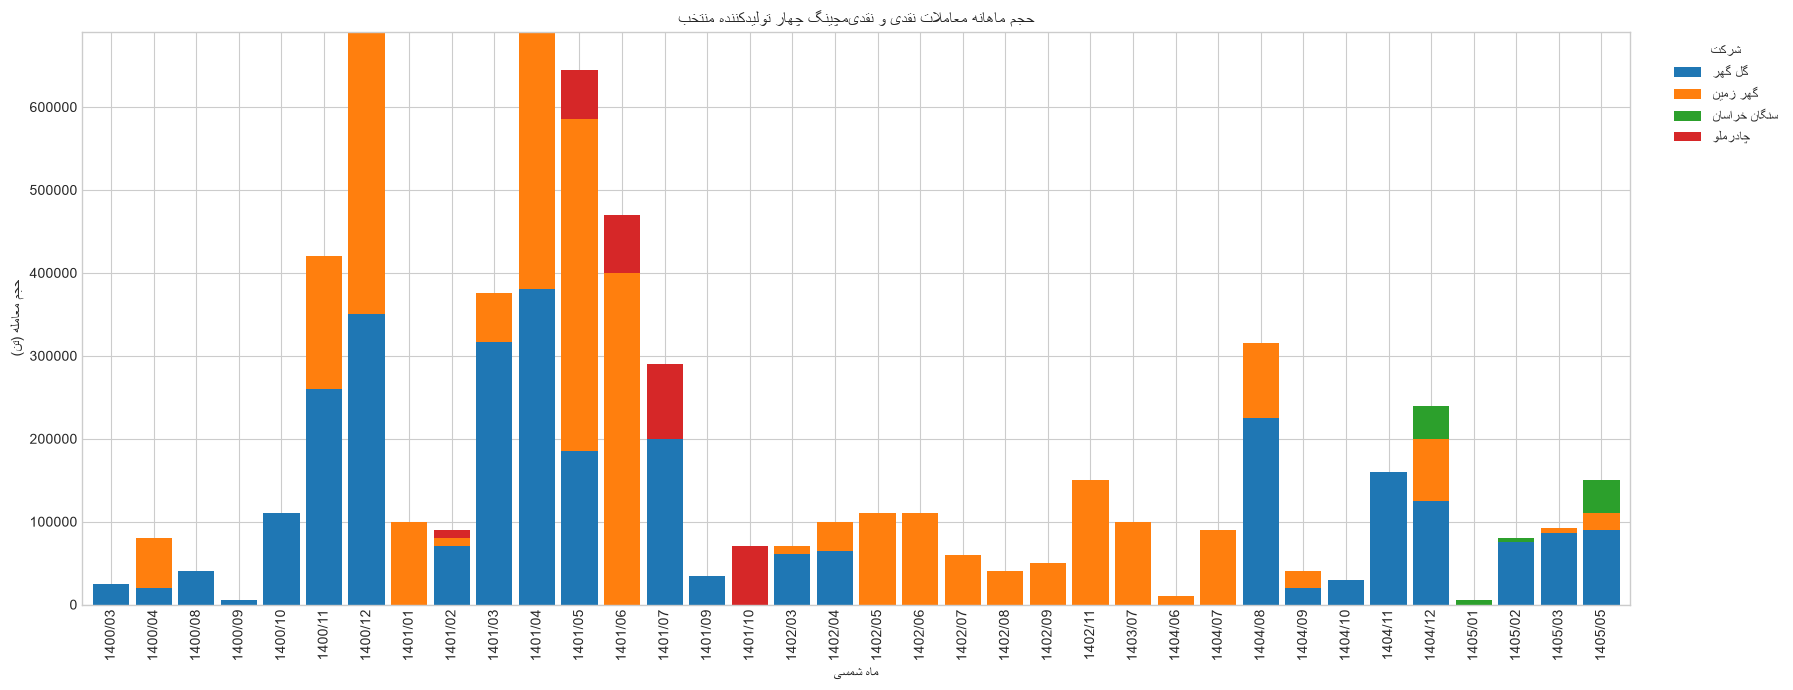

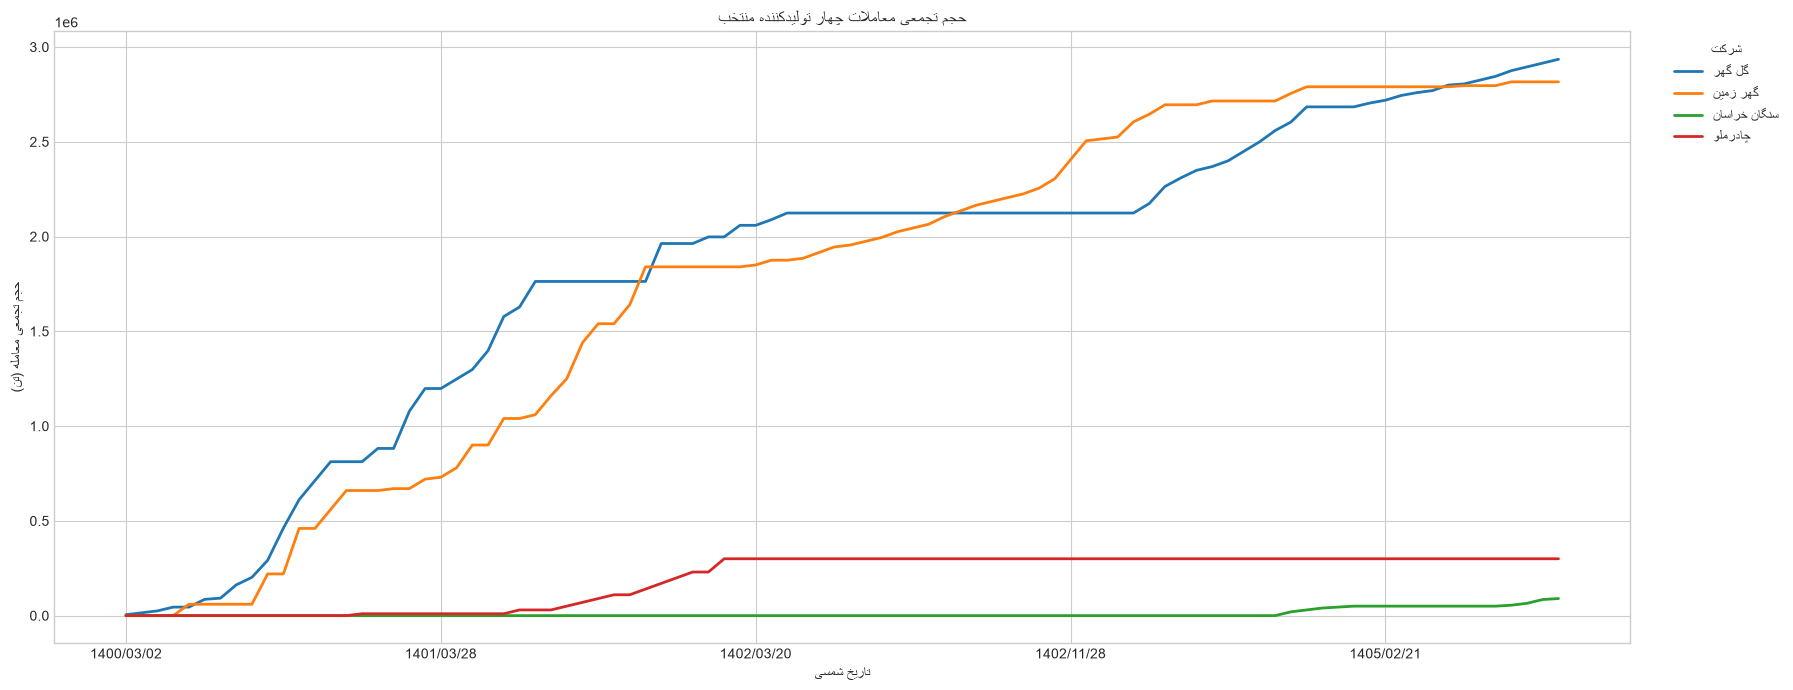

company,گل گهر,گهر زمین,سنگان خراسان,چادرملو
month_jalali,,,,
1403/07,0.0,100000.0,0.0,0.0
1404/06,0.0,10000.0,0.0,0.0
1404/07,0.0,90000.0,0.0,0.0
1404/08,225000.0,90000.0,0.0,0.0
1404/09,20000.0,20000.0,0.0,0.0
1404/10,30000.0,0.0,0.0,0.0
1404/11,160000.0,0.0,0.0,0.0
1404/12,125000.0,75000.0,40000.0,0.0
1405/01,0.0,0.0,5000.0,0.0


In [12]:
selected_trades_full_history = cash.loc[cash["Symbol"].isin(selected_companies)].copy()
selected_trades_full_history["company"] = selected_trades_full_history["Symbol"].map(selected_companies)

full_history_volume_summary = (
    selected_trades_full_history.groupby(["company", "Symbol"], as_index=False)
    .agg(
        first_trade_date=("date_jalali", "min"),
        last_trade_date=("date_jalali", "max"),
        trade_days=("date_jalali", "nunique"),
        trade_rows=("Quantity", "size"),
        total_traded_volume=("Quantity", "sum"),
    )
    .sort_values("total_traded_volume", ascending=False)
    .reset_index(drop=True)
)
full_history_volume_summary["share_within_selected_companies_pct"] = (
    100
    * full_history_volume_summary["total_traded_volume"]
    / full_history_volume_summary["total_traded_volume"].sum()
)
display(full_history_volume_summary)

daily_selected_volume = (
    selected_trades_full_history.groupby(["date_jalali", "company"], as_index=False)
    .agg(traded_volume=("Quantity", "sum"))
)
historical_company_columns = list(selected_companies.values())
daily_volume_wide = (
    daily_selected_volume.pivot(index="date_jalali", columns="company", values="traded_volume")
    .reindex(columns=historical_company_columns)
    .fillna(0)
    .sort_index()
)
daily_volume_wide.index.name = "date_jalali"

monthly_selected_volume = daily_selected_volume.copy()
monthly_selected_volume["month_jalali"] = monthly_selected_volume["date_jalali"].str.slice(0, 7)
monthly_volume_wide = (
    monthly_selected_volume.groupby(["month_jalali", "company"])["traded_volume"].sum()
    .unstack(fill_value=0)
    .reindex(columns=historical_company_columns, fill_value=0)
    .sort_index()
)

ax = monthly_volume_wide.plot(
    kind="bar", stacked=True, figsize=(18, 7), width=0.85
)
ax.set_title("حجم ماهانه معاملات نقدی و نقدی‌مچینگ چهار تولیدکننده منتخب")
ax.set_xlabel("ماه شمسی")
ax.set_ylabel("حجم معامله (تن)")
ax.legend(title="شرکت", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.tick_params(axis="x", rotation=90)
plt.tight_layout()
plt.show()

cumulative_volume = daily_volume_wide.cumsum()
ax = cumulative_volume.plot(figsize=(18, 7), linewidth=2)
ax.set_title("حجم تجمعی معاملات چهار تولیدکننده منتخب")
ax.set_xlabel("تاریخ شمسی")
ax.set_ylabel("حجم تجمعی معامله (تن)")
ax.legend(title="شرکت", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

display(monthly_volume_wide.tail(12))


## 12. Selection checkpoint

Gol Gohar (`GOLG-PELL-00`) and Gohar Zamin (`GHZ-PELL-00`) are retained for the exploratory benchmark because they jointly represent 53.86% of all positive physical volume since certificate inception. Sangan Khorasan (`SSMI-PELL-00`) and Chadormalu (`CHMI-PELL-00`) jointly represent 15.47% and are excluded from the next analytical stage. The decision affects derived analysis only; source observations remain intact.


## 13. Stability of the Gol Gohar–Gohar Zamin price difference

The comparison uses only dates when both selected producers have positive strict-cash observations. Each producer's daily price is volume weighted. The directional difference is `100 × (P_GoharZamin / P_GolGohar - 1)`; a positive value means Gohar Zamin is more expensive. The symmetric difference is also reported to measure dispersion without choosing a denominator.


In [13]:
PAIR_SYMBOLS = {
    "GOLG-PELL-00": "گل گهر",
    "GHZ-PELL-00": "گهر زمین",
}

# Reuse the daily volume-weighted prices constructed above.
selected_pair_daily = daily_company.loc[
    daily_company["Symbol"].isin(PAIR_SYMBOLS)
].copy()

selected_pair_daily["company"] = (
    selected_pair_daily["Symbol"].map(PAIR_SYMBOLS)
)

# Place daily producer prices in separate columns.
pair_price_wide = (
    selected_pair_daily
    .pivot(
        index="date_jalali",
        columns="company",
        values="weighted_price",
    )
    .reindex(columns=list(PAIR_SYMBOLS.values()))
    .sort_index()
)

# Place daily producer volumes in separate columns.
pair_volume_wide = (
    selected_pair_daily
    .pivot(
        index="date_jalali",
        columns="company",
        values="quantity",
    )
    .reindex(columns=list(PAIR_SYMBOLS.values()))
    .sort_index()
)

# Retain only dates when both producers traded.
pair_common_days = (
    pair_price_wide
    .dropna(subset=["گل گهر", "گهر زمین"])
    .copy()
)

pair_common_days = pair_common_days.rename(
    columns={
        "گل گهر": "gol_gohar_price",
        "گهر زمین": "gohar_zamin_price",
    }
)

pair_common_days["gol_gohar_volume"] = (
    pair_volume_wide.loc[
        pair_common_days.index,
        "گل گهر",
    ]
)

pair_common_days["gohar_zamin_volume"] = (
    pair_volume_wide.loc[
        pair_common_days.index,
        "گهر زمین",
    ]
)

# Absolute price difference in IRR/kg.
pair_common_days["gohar_zamin_minus_gol_gohar_irr_per_kg"] = (
    pair_common_days["gohar_zamin_price"]
    - pair_common_days["gol_gohar_price"]
)

# Directional difference: positive means Gohar Zamin was more expensive.
pair_common_days["gohar_zamin_vs_gol_gohar_pct"] = (
    100
    * (
        pair_common_days["gohar_zamin_price"]
        / pair_common_days["gol_gohar_price"]
        - 1
    )
)

# Symmetric absolute difference for homogeneity assessment.
pair_common_days["symmetric_absolute_difference_pct"] = (
    100
    * (
        pair_common_days["gohar_zamin_price"]
        - pair_common_days["gol_gohar_price"]
    ).abs()
    / (
        (
            pair_common_days["gohar_zamin_price"]
            + pair_common_days["gol_gohar_price"]
        )
        / 2
    )
)

# Separate observations before and after certificate inception.
pair_common_days["period"] = np.where(
    pair_common_days.index >= CERTIFICATE_START_DATE,
    "از شروع گواهی",
    "قبل از شروع گواهی",
)

# Identify outliers using the 1.5 × IQR rule.
spread = pair_common_days[
    "gohar_zamin_vs_gol_gohar_pct"
]

q1 = spread.quantile(0.25)
q3 = spread.quantile(0.75)
iqr = q3 - q1

outlier_lower_bound = q1 - 1.5 * iqr
outlier_upper_bound = q3 + 1.5 * iqr

pair_common_days["is_outlier"] = (
    spread.lt(outlier_lower_bound)
    | spread.gt(outlier_upper_bound)
)

pair_common_days.index.name = "date_jalali"

display(
    pair_common_days[
        [
            "gol_gohar_price",
            "gohar_zamin_price",
            "gol_gohar_volume",
            "gohar_zamin_volume",
            "gohar_zamin_minus_gol_gohar_irr_per_kg",
            "gohar_zamin_vs_gol_gohar_pct",
            "symmetric_absolute_difference_pct",
            "period",
            "is_outlier",
        ]
    ]
)

company,gol_gohar_price,gohar_zamin_price,gol_gohar_volume,gohar_zamin_volume,gohar_zamin_minus_gol_gohar_irr_per_kg,gohar_zamin_vs_gol_gohar_pct,symmetric_absolute_difference_pct,period,is_outlier
date_jalali,,,,,,,,,
1400/11/23,36114.0,36114.0,90000.0,160000.0,0.0,0.000000,0.000000,قبل از شروع گواهی,False
1400/12/07,37366.0,36245.0,150000.0,240000.0,-1121.0,-3.000054,3.045740,قبل از شروع گواهی,True
1400/12/21,39839.0,38644.0,100000.0,100000.0,-1195.0,-2.999573,3.045245,قبل از شروع گواهی,True
1401/03/21,34146.0,34146.0,120000.0,50000.0,0.0,0.000000,0.000000,قبل از شروع گواهی,False
1401/04/11,28987.0,31299.0,50000.0,50000.0,2312.0,7.975989,7.670106,قبل از شروع گواهی,True
1401/04/18,29955.0,29955.0,50000.0,120000.0,0.0,0.000000,0.000000,قبل از شروع گواهی,False
1401/04/25,30153.0,30153.0,180000.0,140000.0,0.0,0.000000,0.000000,قبل از شروع گواهی,False
1401/05/08,27056.0,27056.0,135000.0,20000.0,0.0,0.000000,0.000000,قبل از شروع گواهی,False
1402/04/10,45000.0,45000.0,30000.0,25000.0,0.0,0.000000,0.000000,قبل از شروع گواهی,False


In [14]:
pair_period_summary = (
    pair_common_days
    .groupby("period", sort=False)
    .agg(
        common_trade_days=(
            "gohar_zamin_vs_gol_gohar_pct",
            "size",
        ),
        mean_signed_difference_pct=(
            "gohar_zamin_vs_gol_gohar_pct",
            "mean",
        ),
        median_signed_difference_pct=(
            "gohar_zamin_vs_gol_gohar_pct",
            "median",
        ),
        mean_symmetric_difference_pct=(
            "symmetric_absolute_difference_pct",
            "mean",
        ),
        median_symmetric_difference_pct=(
            "symmetric_absolute_difference_pct",
            "median",
        ),
        standard_deviation_pct=(
            "gohar_zamin_vs_gol_gohar_pct",
            "std",
        ),
        minimum_signed_difference_pct=(
            "gohar_zamin_vs_gol_gohar_pct",
            "min",
        ),
        maximum_signed_difference_pct=(
            "gohar_zamin_vs_gol_gohar_pct",
            "max",
        ),
        outlier_days=("is_outlier", "sum"),
    )
    .reset_index()
)

display(pair_period_summary)

display(
    pd.Series(
        {
            "first_common_date": pair_common_days.index.min(),
            "last_common_date": pair_common_days.index.max(),
            "total_common_trade_days": len(pair_common_days),
            "gohar_zamin_more_expensive_days": int(
                pair_common_days[
                    "gohar_zamin_vs_gol_gohar_pct"
                ].gt(0).sum()
            ),
            "gol_gohar_more_expensive_days": int(
                pair_common_days[
                    "gohar_zamin_vs_gol_gohar_pct"
                ].lt(0).sum()
            ),
            "equal_price_days": int(
                pair_common_days[
                    "gohar_zamin_vs_gol_gohar_pct"
                ].eq(0).sum()
            ),
            "iqr_lower_bound_pct": outlier_lower_bound,
            "iqr_upper_bound_pct": outlier_upper_bound,
            "outlier_days": int(
                pair_common_days["is_outlier"].sum()
            ),
        },
        name="value",
    ).to_frame()
)

,period,common_trade_days,mean_signed_difference_pct,median_signed_difference_pct,mean_symmetric_difference_pct,median_symmetric_difference_pct,standard_deviation_pct,minimum_signed_difference_pct,maximum_signed_difference_pct,outlier_days
0,قبل از شروع گواهی,9,0.219596,0.0,1.529010,0.0,3.185517,-3.000054,7.975989,3
1,از شروع گواهی,7,-0.485894,0.0,0.880307,0.0,1.475722,-3.269098,1.352272,3


,value
first_common_date,1400/11/23
last_common_date,1405/05/05
total_common_trade_days,16
gohar_zamin_more_expensive_days,2
gol_gohar_more_expensive_days,4
equal_price_days,10
iqr_lower_bound_pct,-0.927772
iqr_upper_bound_pct,0.556663
outlier_days,6


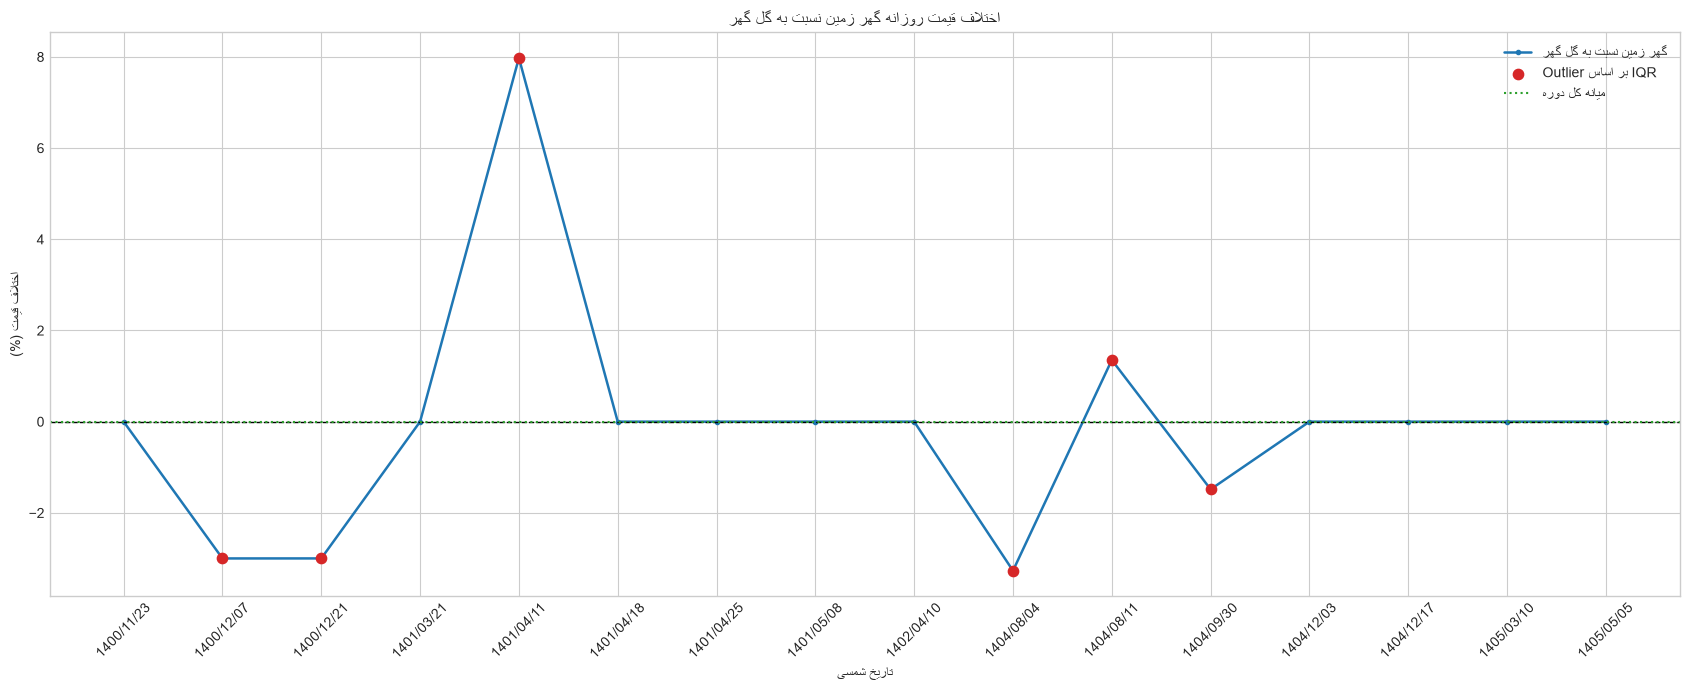

In [15]:
plot_pair = pair_common_days.reset_index()

fig, ax = plt.subplots(figsize=(17, 7))

ax.plot(
    plot_pair["date_jalali"],
    plot_pair["gohar_zamin_vs_gol_gohar_pct"],
    color="tab:blue",
    linewidth=1.8,
    marker="o",
    markersize=3,
    label="گهر زمین نسبت به گل گهر",
)

outlier_plot = plot_pair.loc[
    plot_pair["is_outlier"]
]

ax.scatter(
    outlier_plot["date_jalali"],
    outlier_plot["gohar_zamin_vs_gol_gohar_pct"],
    color="tab:red",
    s=55,
    zorder=3,
    label="Outlier بر اساس IQR",
)

ax.axhline(
    0,
    color="black",
    linewidth=1,
    linestyle="--",
)

ax.axhline(
    spread.median(),
    color="tab:green",
    linewidth=1.5,
    linestyle=":",
    label="میانه کل دوره",
)

# Thin date labels for readability.
tick_step = max(len(plot_pair) // 12, 1)

ax.set_xticks(
    plot_pair["date_jalali"].iloc[::tick_step]
)

ax.tick_params(axis="x", rotation=45)

ax.set_title(
    "اختلاف قیمت روزانه گهر زمین نسبت به گل گهر"
)

ax.set_xlabel("تاریخ شمسی")
ax.set_ylabel("اختلاف قیمت (%)")
ax.legend()
plt.tight_layout()
plt.show()

### Audit of three deleted observations after modification of settlement type
Three dates that were seen as unusual in the previous definition—`1404/10/21`, `1404/11/12`, and `1404/12/03`—are kept for audit. After the requirement of full cash settlement, the first two dates are no longer a common point, and on the third date, the cash price of the two companies is equal.

In [16]:
FORMER_ANOMALY_DATES = ["1404/10/21", "1404/11/12", "1404/12/03"]

remaining_common_dates = [
    date for date in FORMER_ANOMALY_DATES if date in pair_common_days.index
]
former_anomaly_comparison = pair_common_days.reindex(FORMER_ANOMALY_DATES)
display(former_anomaly_comparison)

former_anomaly_raw_rows = (
    raw.loc[
        raw["Symbol"].isin(PAIR_SYMBOLS)
        & raw["date_jalali"].isin(FORMER_ANOMALY_DATES)
        & raw["ContractType"].isin(cash_contracts)
        & raw["Quantity"].gt(0)
        & raw["Price"].gt(0),
        [
            "date_jalali", "Symbol", "ProducerName", "ContractType",
            "Tasvieh", "Price", "Quantity", "TotalPrice",
            "arze", "ArzeBasePrice", "taghaza", "DeliveryDate",
            "Warehouse", "arzehPk",
        ],
    ]
    .sort_values(["date_jalali", "Symbol", "Tasvieh", "Price"])
    .reset_index(drop=True)
)
display(former_anomaly_raw_rows)

anomaly_settlement = former_anomaly_raw_rows.copy()
anomaly_settlement["company"] = anomaly_settlement["Symbol"].map(PAIR_SYMBOLS)
anomaly_settlement["price_x_quantity"] = (
    anomaly_settlement["Price"] * anomaly_settlement["Quantity"]
)
anomaly_settlement_summary = (
    anomaly_settlement.groupby(["date_jalali", "company", "Tasvieh"], as_index=False)
    .agg(
        price_x_quantity=("price_x_quantity", "sum"),
        traded_volume=("Quantity", "sum"),
        source_rows=("Quantity", "size"),
        base_prices=("ArzeBasePrice", lambda x: " | ".join(sorted(set(x.dropna().astype(str))))),
        delivery_dates=("DeliveryDate", lambda x: " | ".join(sorted(set(x.dropna().astype(str))))),
    )
)
anomaly_settlement_summary["weighted_price_irr_per_kg"] = (
    anomaly_settlement_summary["price_x_quantity"]
    / anomaly_settlement_summary["traded_volume"]
)
display(anomaly_settlement_summary.drop(columns="price_x_quantity"))


company,gol_gohar_price,gohar_zamin_price,gol_gohar_volume,gohar_zamin_volume,gohar_zamin_minus_gol_gohar_irr_per_kg,gohar_zamin_vs_gol_gohar_pct,symmetric_absolute_difference_pct,period,is_outlier
date_jalali,,,,,,,,,
1404/10/21,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1404/11/12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1404/12/03,104471.0,104471.0,45000.0,40000.0,0.0,0.0,0.0,از شروع گواهی,False


,date_jalali,Symbol,ProducerName,ContractType,Tasvieh,Price,Quantity,TotalPrice,arze,ArzeBasePrice,taghaza,DeliveryDate,Warehouse,arzehPk
0,1404/10/21,GHZ-PELL-00,معدنی و صنعتی گهر زمین (سنگ آهن گهر زمین),نقدی,نقدی / اعتباری,111229.0,100000.0,1.112290e+10,100000.0,86562.0,263000.0,1404/10/24,انبار کارخانه,1156678
1,1404/10/21,GOLG-PELL-00,معدنی و صنعتی گل گهر,نقدی,نقدی,94566.0,30000.0,2.836970e+09,30000.0,86562.0,70000.0,1404/10/24,انبار کارخانه,1156680
2,1404/11/12,GHZ-PELL-00,معدنی و صنعتی گهر زمین (سنگ آهن گهر زمین),نقدی,نقدی / اعتباری,121691.0,65000.0,7.909935e+09,65000.0,95606.0,191000.0,1404/11/18,انبار کارخانه,1170516
3,1404/11/12,GOLG-PELL-00,معدنی و صنعتی گل گهر,نقدی,نقدی,98679.0,50000.0,4.933950e+09,50000.0,95606.0,75000.0,1404/11/18,انبار کارخانه,1170527
4,1404/12/03,GHZ-PELL-00,معدنی و صنعتی گهر زمین (سنگ آهن گهر زمین),نقدی (مچینگ),نقدی,104471.0,16000.0,1.671536e+09,0.0,104471.0,16000.0,1404/12/06,انبار کارخانه,1188446
5,1404/12/03,GHZ-PELL-00,معدنی و صنعتی گهر زمین (سنگ آهن گهر زمین),نقدی,نقدی,104471.0,24000.0,2.507304e+09,40000.0,104471.0,38000.0,1404/12/06,انبار کارخانه,1188446
6,1404/12/03,GHZ-PELL-00,معدنی و صنعتی گهر زمین (سنگ آهن گهر زمین),نقدی,نقدی / اعتباری,117222.0,60000.0,7.033290e+09,60000.0,104471.0,150000.0,1404/12/06,انبار کارخانه,1188444
7,1404/12/03,GOLG-PELL-00,معدنی و صنعتی گل گهر,نقدی,نقدی,104471.0,45000.0,4.701195e+09,60000.0,104471.0,45000.0,1404/12/06,انبار کارخانه,1188449


,date_jalali,company,Tasvieh,traded_volume,source_rows,base_prices,delivery_dates,weighted_price_irr_per_kg
0,1404/10/21,گل گهر,نقدی,30000.0,1,86562.0,1404/10/24,94566.0
1,1404/10/21,گهر زمین,نقدی / اعتباری,100000.0,1,86562.0,1404/10/24,111229.0
2,1404/11/12,گل گهر,نقدی,50000.0,1,95606.0,1404/11/18,98679.0
3,1404/11/12,گهر زمین,نقدی / اعتباری,65000.0,1,95606.0,1404/11/18,121691.0
4,1404/12/03,گل گهر,نقدی,45000.0,1,104471.0,1404/12/06,104471.0
5,1404/12/03,گهر زمین,نقدی,40000.0,2,104471.0,1404/12/06,104471.0
6,1404/12/03,گهر زمین,نقدی / اعتباری,60000.0,1,104471.0,1404/12/06,117222.0


### Interpretation and market-event audit

The conventional percentage difference depends on which producer is the denominator. The symmetric measure, `100 × |P2 - P1| / ((P1 + P2) / 2)`, is invariant to producer order and is appropriate for homogeneity assessment; direction remains available in `gohar_zamin_vs_gol_gohar_pct`.

Several apparent outliers disappear after enforcing strict-cash settlement because Gohar Zamin traded only on cash/credit terms. Those rows remain in raw data but are correctly excluded from the benchmark. Remaining common-date differences are reviewed against base price, offer, demand, delivery, warehouse, and settlement fields rather than being removed mechanically.


### Case study: producer price difference on 1401/04/11

This date has the largest symmetric difference among valid common strict-cash observations. The two source offers are audited directly to compare base price, supply, demand, delivery, warehouse, and settlement conditions.


In [17]:
CASE_DATE = "1401/04/11"

case_1401_04_11 = (
    cash.loc[
        cash["date_jalali"].eq(CASE_DATE)
        & cash["Symbol"].isin(PAIR_SYMBOLS),
        [
            "date_jalali", "Symbol", "ProducerName", "ContractType",
            "Tasvieh", "ArzeBasePrice", "arze", "taghaza",
            "MinPrice", "Price", "MaxPrice", "Quantity",
            "TotalPrice", "DeliveryDate", "Warehouse", "arzehPk",
        ],
    ]
    .sort_values("Symbol")
    .reset_index(drop=True)
)
case_1401_04_11["demand_to_offer_ratio"] = (
    case_1401_04_11["taghaza"] / case_1401_04_11["arze"]
)
case_1401_04_11["price_premium_over_base_pct"] = 100 * (
    case_1401_04_11["Price"] / case_1401_04_11["ArzeBasePrice"] - 1
)
display(case_1401_04_11)
display(pair_common_days.loc[[CASE_DATE]])


,date_jalali,Symbol,ProducerName,ContractType,Tasvieh,ArzeBasePrice,arze,taghaza,MinPrice,Price,MaxPrice,Quantity,TotalPrice,DeliveryDate,Warehouse,arzehPk,demand_to_offer_ratio,price_premium_over_base_pct
0,1401/04/11,GHZ-PELL-00,سنگ آهن گهر زمین,نقدی,نقدی,28298.0,50000.0,150000.0,31299.0,31299.0,31299.0,50000.0,1.564950e+09,1401/04/14,انبار کارخانه,551987,3.0,10.604990
1,1401/04/11,GOLG-PELL-00,معدنی و صنعتی گل گهر,نقدی,نقدی,28298.0,50000.0,65000.0,28600.0,28987.0,30109.0,50000.0,1.449355e+09,1401/04/14,انبار کارخانه,551989,1.3,2.434801


company,gol_gohar_price,gohar_zamin_price,gol_gohar_volume,gohar_zamin_volume,gohar_zamin_minus_gol_gohar_irr_per_kg,gohar_zamin_vs_gol_gohar_pct,symmetric_absolute_difference_pct,period,is_outlier
date_jalali,,,,,,,,,
1401/04/11,28987.0,31299.0,50000.0,50000.0,2312.0,7.975989,7.670106,قبل از شروع گواهی,True


On `1401/04/11`, both offers have a base price of IRR 28,298/kg, an offer quantity of 50,000 tonnes, factory delivery on `1401/04/14`, and fully cash settlement. Gol Gohar demand is 65,000 tonnes (1.3 times supply) and its weighted price is IRR 28,987/kg, 2.43% above base. Gohar Zamin demand is 150,000 tonnes (3.0 times supply) and its price is IRR 31,299/kg, 10.60% above base. The directional difference is 7.98% and the symmetric difference is 7.67%. Stronger observed competition explains the immediate price formation, but the data do not identify the underlying cause of buyer preference.


## 14. Certificate bubble relative to the selected physical benchmark

An eligible physical date requires at least one selected producer to have a strict-cash trade. A single-producer date uses that producer's price; a two-producer date uses the simple mean. The certificate is joined only on exact dates with positive volume and settlement price. Bubble is `100 × (certificate settlement / physical benchmark - 1)`: positive values are premiums and negative values are discounts. No interpolation or carry-forward is used.


,date_jalali,gol_gohar_price,gohar_zamin_price,physical_mean_price_irr_per_kg,TodaySettlementPrice,certificate_minus_physical_irr_per_kg,certificate_vs_physical_bubble_pct,physical_company_count,physical_price_method,TradesVolume
0,1404/08/04,76749.0,74240.0,75494.5,68388.0,-7106.5,-9.413269,2,simple_mean_of_two,2742
1,1404/08/11,73358.0,74350.0,73854.0,68347.0,-5507.0,-7.456604,2,simple_mean_of_two,72
2,1404/08/18,75270.0,NaN,75270.0,67886.0,-7384.0,-9.810017,1,single_available_company,481
3,1404/08/25,75985.0,NaN,75985.0,67708.0,-8277.0,-10.892939,1,single_available_company,39
4,1404/09/30,76999.0,75856.0,76427.5,69664.0,-6763.5,-8.849563,2,simple_mean_of_two,524227
5,1404/10/21,94566.0,NaN,94566.0,104998.0,10432.0,11.031449,1,single_available_company,208726
6,1404/11/12,98679.0,NaN,98679.0,95888.0,-2791.0,-2.828363,1,single_available_company,29831
7,1404/11/19,98474.0,NaN,98474.0,96028.0,-2446.0,-2.483904,1,single_available_company,24584
8,1404/11/26,101428.0,NaN,101428.0,95871.0,-5557.0,-5.478763,1,single_available_company,5339
9,1404/12/03,104471.0,104471.0,104471.0,95218.0,-9253.0,-8.857003,2,simple_mean_of_two,16654


,observations
physical_price_method,
single_available_company,17
simple_mean_of_two,6


,value
observations,23.000000
mean_pct,-12.183581
median_pct,-12.067500
min_pct,-24.926282
max_pct,11.031449


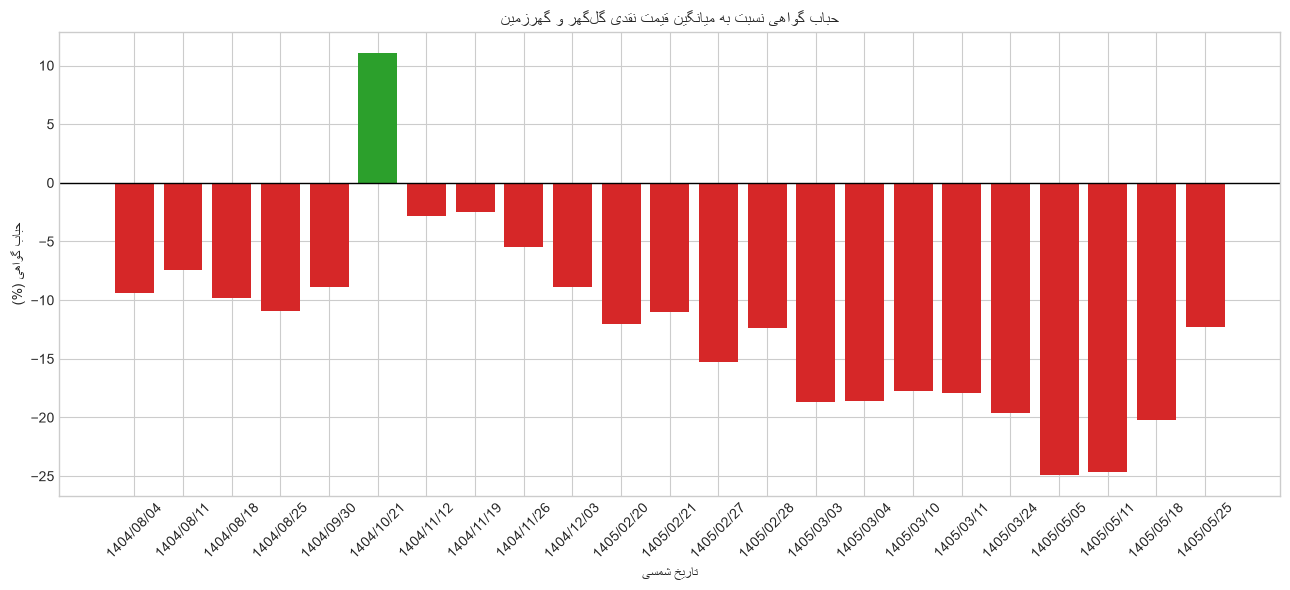

In [18]:
CERTIFICATE_CSV = Path("../data/raw/certificate/pellet_certificate_raw.csv")
if not CERTIFICATE_CSV.exists():
    raise FileNotFoundError(f"Certificate raw file not found: {CERTIFICATE_CSV.resolve()}")

certificate_raw = pd.read_csv(CERTIFICATE_CSV, encoding="utf-8-sig", low_memory=False)
for column in ["TradesVolume", "TradesValue", "TodaySettlementPrice"]:
    certificate_raw[column] = pd.to_numeric(certificate_raw[column], errors="raise")

if certificate_raw["PersianDate"].duplicated().any():
    raise ValueError("Certificate PersianDate must be unique")

certificate_traded = certificate_raw.loc[
    certificate_raw["TradesVolume"].gt(0)
    & certificate_raw["TodaySettlementPrice"].gt(0),
    ["PersianDate", "DT", "ContractCode", "TradesVolume",
     "TradesValue", "TodaySettlementPrice"],
].copy()

physical_pair_benchmark = pair_price_wide.rename(columns={
    "گل گهر": "gol_gohar_price",
    "گهر زمین": "gohar_zamin_price",
}).copy()
physical_pair_benchmark["gol_gohar_volume"] = pair_volume_wide["گل گهر"]
physical_pair_benchmark["gohar_zamin_volume"] = pair_volume_wide["گهر زمین"]
physical_pair_benchmark["physical_company_count"] = (
    physical_pair_benchmark[["gol_gohar_price", "gohar_zamin_price"]]
    .notna().sum(axis=1)
)
physical_pair_benchmark["physical_mean_price_irr_per_kg"] = (
    physical_pair_benchmark[["gol_gohar_price", "gohar_zamin_price"]]
    .mean(axis=1, skipna=True)
)
physical_pair_benchmark["physical_price_method"] = np.where(
    physical_pair_benchmark["physical_company_count"].eq(2),
    "simple_mean_of_two",
    "single_available_company",
)
physical_pair_benchmark = physical_pair_benchmark.reset_index()

certificate_bubble_exact = physical_pair_benchmark.merge(
    certificate_traded,
    left_on="date_jalali",
    right_on="PersianDate",
    how="inner",
    validate="one_to_one",
).sort_values("date_jalali").reset_index(drop=True)

certificate_bubble_exact["certificate_minus_physical_irr_per_kg"] = (
    certificate_bubble_exact["TodaySettlementPrice"]
    - certificate_bubble_exact["physical_mean_price_irr_per_kg"]
)
certificate_bubble_exact["certificate_vs_physical_bubble_pct"] = 100 * (
    certificate_bubble_exact["TodaySettlementPrice"]
    / certificate_bubble_exact["physical_mean_price_irr_per_kg"]
    - 1
)

if certificate_bubble_exact.empty:
    raise ValueError("No exact-date overlap between the physical pair and traded certificate")

display(certificate_bubble_exact[[
    "date_jalali", "gol_gohar_price", "gohar_zamin_price",
    "physical_mean_price_irr_per_kg", "TodaySettlementPrice",
    "certificate_minus_physical_irr_per_kg",
    "certificate_vs_physical_bubble_pct", "physical_company_count",
    "physical_price_method", "TradesVolume",
]])
display(certificate_bubble_exact["physical_price_method"].value_counts().to_frame("observations"))
display(certificate_bubble_exact["certificate_vs_physical_bubble_pct"].agg(
    observations="count", mean_pct="mean", median_pct="median",
    min_pct="min", max_pct="max",
).to_frame("value"))

bubble_colors = np.where(
    certificate_bubble_exact["certificate_vs_physical_bubble_pct"].ge(0),
    "tab:green",
    "tab:red",
)
fig, ax = plt.subplots(figsize=(13, 6))
ax.bar(
    certificate_bubble_exact["date_jalali"],
    certificate_bubble_exact["certificate_vs_physical_bubble_pct"],
    color=bubble_colors,
)
ax.axhline(0, color="black", linewidth=1)
ax.set_title("حباب گواهی نسبت به میانگین قیمت نقدی گل‌گهر و گهرزمین")
ax.set_xlabel("تاریخ شمسی")
ax.set_ylabel("حباب گواهی (%)")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()


In exact-date overlap with positive certificate transactions, 22 observations were obtained: 6 two-company days and 16 single-company days. The average bubble is 12.18% and its median is 11.55%; The range varies from -24.93% to +11.03% and is only a positive observation. Therefore, in this example, the certificate is mainly traded at a discount compared to the physical benchmark. However, since 16 observations are made from the price of only one company, the dominance of single-company days should be explicitly considered in the sensitivity analysis and final conclusions. The comparison is exact-date only and no old price, interpolation or carry-forward is used.

## 15. Case study: the only positive bubble on 1404/10/21

The certificate settles at IRR 104,998/kg and the qualifying Gol Gohar cash benchmark is IRR 94,566/kg, producing a +11.03% bubble. Gohar Zamin trades at IRR 111,229/kg but is excluded because settlement is cash/credit. A sensitivity mean using both same-day producer prices reduces the bubble to approximately +2.04%, showing that the official observation is materially composition-sensitive.

Certificate settlement had already increased from IRR 81,844/kg on 1404/10/10 to IRR 103,483/kg on 1404/10/17. The evidence is consistent with an earlier adjustment in the continuously traded certificate than in the intermittent physical market, but it does not establish causality. The observation is retained and labeled as a single-producer, composition-sensitive benchmark.


## Standard market dashboard

This governed, read-only section uses the same presentation contract across commodity projects:
source coverage, physical and certificate activity, separate price panels, physical-goods
composition, and validated processed bubbles. It never writes raw data or constructs a missing
bubble. For Pellet, product comparability still follows the project-specific workflow.

,source_records,positive_trade_records,trading_days,first_date,last_date
market,,,,,
physical,3535,1658,367,1397/04/13,1405/06/07
certificate,268,194,194,1404/07/28,1405/06/05


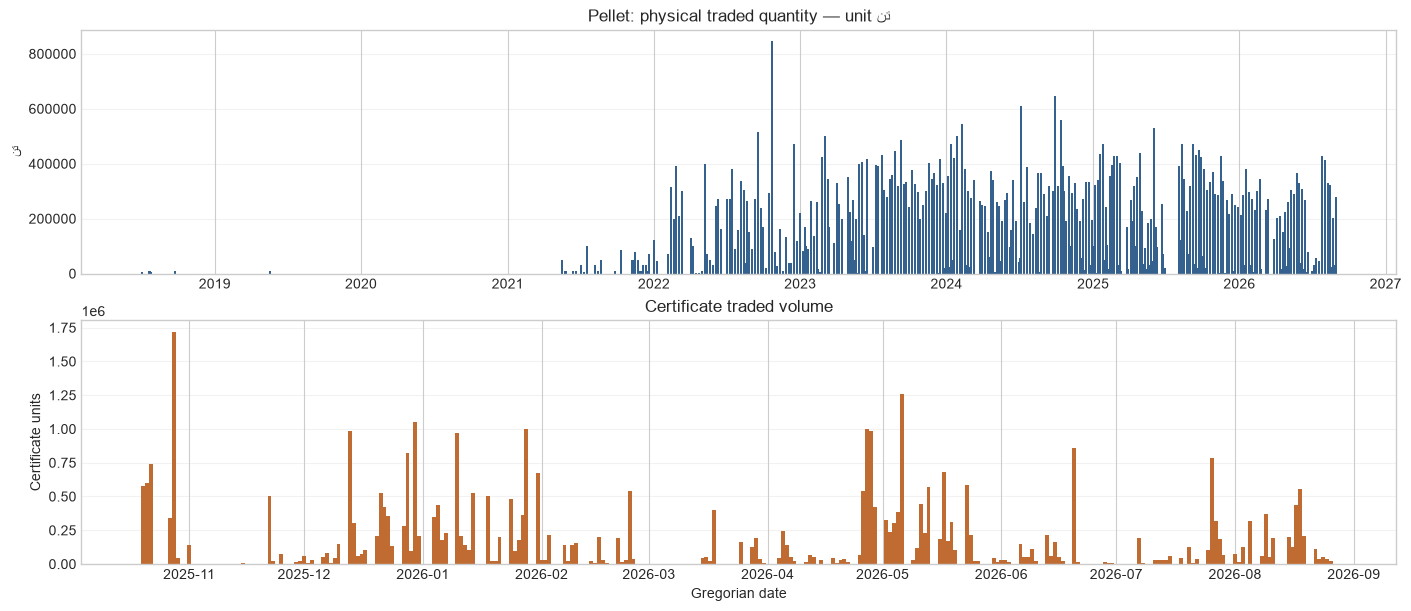

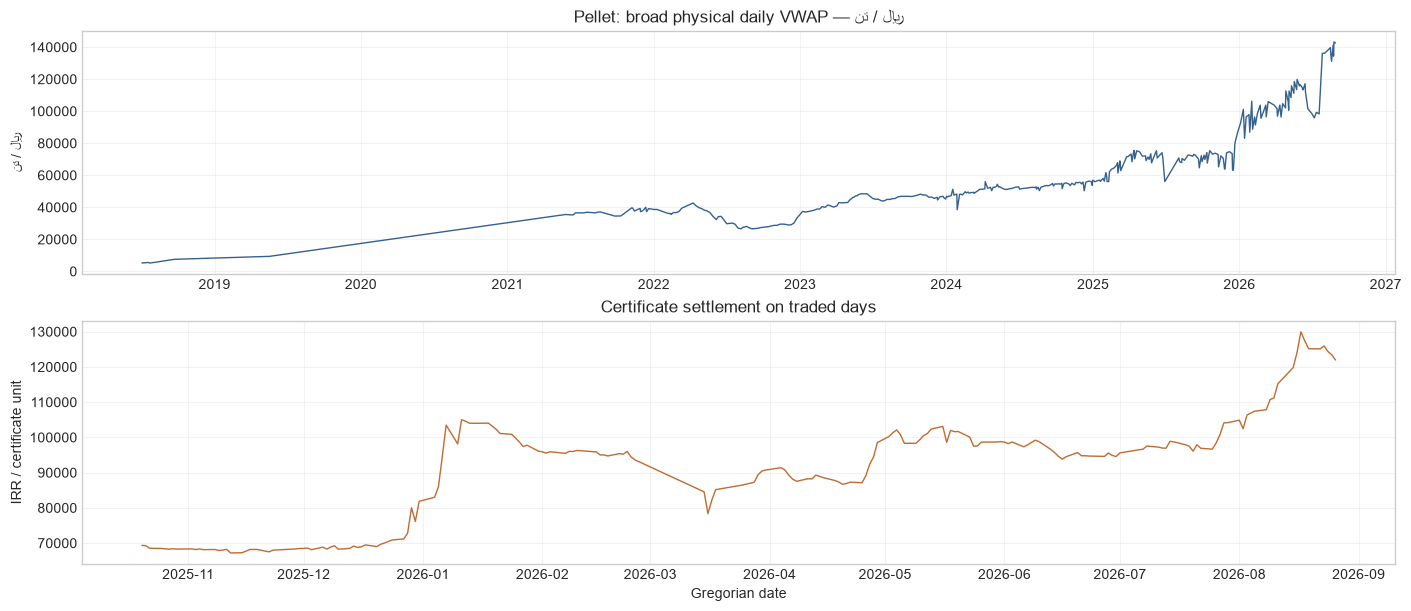

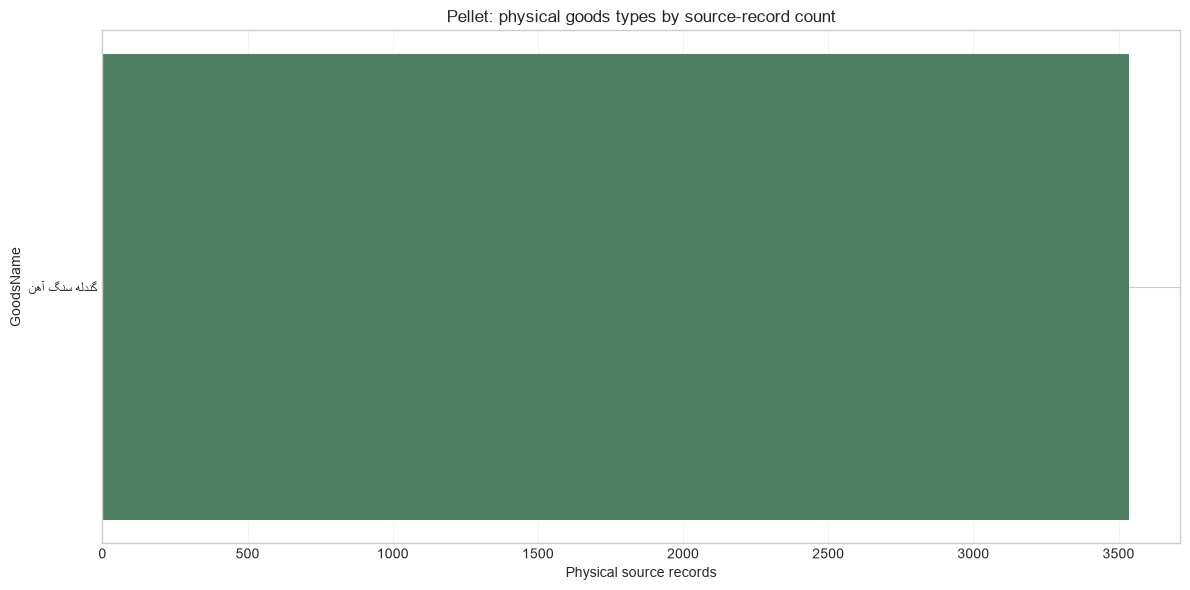

Distinct physical GoodsName labels: 1; records counted: 3,535


,goods_name,record_count,share_pct
0,گندله سنگ آهن,3535,100.0


No validated processed bubble dataset exists. No bubble was calculated or inferred in this notebook.


In [19]:
from pathlib import Path
import sys

def locate_workspace(start=Path.cwd()):
    for candidate in [start, *start.parents]:
        if (candidate / "commodity" / "pellet").exists() and (candidate / "shared").exists():
            return candidate
    raise FileNotFoundError("Could not locate workspace root")

WORKSPACE_ROOT = locate_workspace()
if str(WORKSPACE_ROOT) not in sys.path:
    sys.path.insert(0, str(WORKSPACE_ROOT))

from shared.notebook_tools.commodity_dashboard import (
    goods_type_counts,
    load_markets,
    market_summary,
    plot_available_bubbles,
    plot_goods_type_counts,
    plot_market_prices,
    plot_trade_activity,
)

PROJECT_DIR = WORKSPACE_ROOT / "commodity" / "pellet"
physical_dashboard, certificate_dashboard = load_markets(
    PROJECT_DIR, "pellet", physical_filename=None
)
display(market_summary(physical_dashboard, certificate_dashboard))
plot_trade_activity(physical_dashboard, certificate_dashboard, "Pellet")
plot_market_prices(physical_dashboard, certificate_dashboard, "Pellet")
goods_count_table = plot_goods_type_counts(physical_dashboard, "Pellet", top_n=30)
display(goods_count_table)
bubble_series_plotted = plot_available_bubbles(PROJECT_DIR, "Pellet")